Author: Andreas Loizias
Created: 2026-03-16
Description: This is the second notebook for the card fraud model. In this notebook we will train various models and chose the best.

In [1]:
#import all the split datasets
import numpy as np

x_train = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/X_train.npy")
x_val = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/X_val.npy")
x_test = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/X_test.npy")

y_train = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/y_train.npy")
y_val = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/y_val.npy")
y_test = np.load("/kaggle/input/datasets/andreasloizias/cardfraudsplit/y_test.npy")

In [2]:
#ensure the datasets were loaded correctly
print("x_train shape:", x_train.shape)
print("x_val shape:", x_val.shape)
print("x_test shape:", x_test.shape)

print("y_train shape:", y_train.shape)
print("y_val shape:", y_val.shape)
print("y_test shape:", y_test.shape)

x_train shape: (182276, 30)
x_val shape: (45569, 30)
x_test shape: (56962, 30)
y_train shape: (182276,)
y_val shape: (45569,)
y_test shape: (56962,)


We train our first mode using linear regression

In [3]:
#define linear regression mode and train
#the class weight must be balanced because our fraud datasets are extremely imbalanced
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, class_weight="balanced")

model.fit(x_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [4]:
#validate the linear regression model
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_val_pred = model.predict(x_val)
y_val_prob = model.predict_proba(x_val)[:,1]

print(classification_report(y_val, y_val_pred))
print("ROC AUC:", roc_auc_score(y_val, y_val_prob))
print(confusion_matrix(y_val, y_val_pred))

              precision    recall  f1-score   support

           0       1.00      0.98      0.99     45490
           1       0.06      0.91      0.12        79

    accuracy                           0.98     45569
   macro avg       0.53      0.94      0.55     45569
weighted avg       1.00      0.98      0.99     45569

ROC AUC: 0.9786657799321593
[[44444  1046]
 [    7    72]]


We see that 91% of fraud transactions were detected correctly but precision was only 0.06 which is low as fraud is very rare. The confusion matrix shows as that 55620 True negatives were detected, 7 false positives were detected, 72 true positives were detected and 1046 false positives were detected. This means that even though we got many false positives, the true positives vs false positives was good, which is better to chase wrongfully marked fraud cases but not lose many true fraud cases.

Next we train a random forrest with 200 trees, again balanced class weights since our dataset is highly unbalanced.

In [5]:
#define and train random forest
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight="balanced",
    random_state=22,
    n_jobs=-1
)

rf.fit(x_train, y_train)

RandomForestClassifier(class_weight='balanced', n_estimators=200, n_jobs=-1,
                       random_state=22)

In [6]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, average_precision_score

y_val_pred_rf = rf.predict(x_val)
y_val_prob_rf = rf.predict_proba(x_val)[:,1]

print(classification_report(y_val, y_val_pred_rf))
print("ROC AUC:", roc_auc_score(y_val, y_val_prob_rf))
print(confusion_matrix(y_val, y_val_pred_rf))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.95      0.80      0.87        79

    accuracy                           1.00     45569
   macro avg       0.98      0.90      0.93     45569
weighted avg       1.00      1.00      1.00     45569

ROC AUC: 0.9598561097027862
[[45487     3]
 [   16    63]]


With the random forest, the recall dropped to 0.8 but accuracy went up. The confusion matrix tells that the there were 45487 True negatives, only 3 false positives, 16 false negatives, and 63 true positives. This means that it generated far fewer false positives so less chasing after valid transactions, but it also missed more true fraud cases.

In [7]:
#change the threshold to 0.3 and test again
y_prob = rf.predict_proba(x_val)[:,1]

pred = (y_prob > 0.3).astype(int)

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

print(classification_report(y_val, pred))
print(confusion_matrix(y_val, pred))
print("ROC AUC:", roc_auc_score(y_val, y_prob))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     45490
           1       0.90      0.82      0.86        79

    accuracy                           1.00     45569
   macro avg       0.95      0.91      0.93     45569
weighted avg       1.00      1.00      1.00     45569

[[45483     7]
 [   14    65]]
ROC AUC: 0.9598561097027862


We see that after threshold tuning, the precision went slightly down but recall went up a bit... 65 True positives so slightly better and 7 false positives. Overall not a great improvement.

Now we will define and train Neural Networks model.

In [8]:
#import tensorflow and keras libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

2026-03-17 07:17:50.748662: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1773731871.043126      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1773731871.118561      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1773731871.791614      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773731871.791668      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1773731871.791671      55 computation_placer.cc:177] computation placer alr

In [10]:
#define a simple neural network with two hidden layers with relu activation function and one output layer with sigmoid activation function since it is a binary class output. We use droupout
model = keras.Sequential([
    layers.Input(shape=(x_train.shape[1],)),
    layers.Dense(32, activation="relu"),
    layers.Dropout(0.3),
    layers.Dense(16, activation="relu"),
    layers.Dropout(0.2),
    layers.Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=[
        keras.metrics.Precision(name="precision"),
        keras.metrics.Recall(name="recall"),
        keras.metrics.AUC(name="auc"),
        keras.metrics.AUC(name="pr_auc", curve="PR")
    ]
)

model.summary()

2026-03-17 07:18:39.801331: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,537 (6.00 KB)

 Trainable params: 1,537 (6.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
#use class weights because our dataset is highly imbalanced
neg, pos = np.bincount(y_train.astype(int))
total = neg + pos

class_weight = {
    0: total / (2 * neg),
    1: total / (2 * pos)
}

print("Class weights:", class_weight)

Class weights: {0: np.float64(0.5008655700946906), 1: np.float64(289.32698412698414)}


In [13]:
#train over 20 epochs using early stopping
early_stopping = keras.callbacks.EarlyStopping(
    monitor="val_pr_auc",
    mode="max",
    patience=3,
    restore_best_weights=True
)

history = model.fit(
    x_train,
    y_train,
    validation_split=0.2,
    epochs=20,
    batch_size=2048,
    class_weight=class_weight,
    callbacks=[early_stopping],
    verbose=1
)

Epoch 1/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - auc: 0.5913 - loss: 0.8477 - pr_auc: 0.0604 - precision: 0.0021 - recall: 0.5675 - val_auc: 0.9783 - val_loss: 0.4951 - val_pr_auc: 0.7220 - val_precision: 0.0128 - val_recall: 0.9623
Epoch 2/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.8871 - loss: 0.3935 - pr_auc: 0.4735 - precision: 0.0068 - recall: 0.8242 - val_auc: 0.9807 - val_loss: 0.3409 - val_pr_auc: 0.7633 - val_precision: 0.0609 - val_recall: 0.9623
Epoch 3/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9373 - loss: 0.3243 - pr_auc: 0.5392 - precision: 0.0157 - recall: 0.8574 - val_auc: 0.9829 - val_loss: 0.2616 - val_pr_auc: 0.7728 - val_precision: 0.0725 - val_recall: 0.9623
Epoch 4/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc: 0.9448 - loss: 0.2579 - pr_auc: 0.5597 - precision: 0.0251 - recall: 0.8849 - val_auc: 0.9852 - val_loss: 0.2165 - val_pr_auc: 0.7848 - val_precision: 0.0703 - val_recall: 0.9623
Epoch 5/20
72/72 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - auc

In [14]:
#evaluate the model on unseen data
y_prob = model.predict(x_test).ravel()
y_pred = (y_prob >= 0.5).astype(int)

1781/1781 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step  


In [15]:
#view the metrics
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

roc_auc = roc_auc_score(y_test, y_prob)
pr_auc = average_precision_score(y_test, y_prob)

print("ROC-AUC:", roc_auc)
print("PR-AUC:", pr_auc)

Confusion Matrix:
[[55879   985]
 [    8    90]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9999    0.9827    0.9912     56864
           1     0.0837    0.9184    0.1535        98

    accuracy                         0.9826     56962
   macro avg     0.5418    0.9505    0.5723     56962
weighted avg     0.9983    0.9826    0.9898     56962

ROC-AUC: 0.963718212735291
PR-AUC: 0.6702729803321877


We see from the confusion matrix that it detected 90 true fraud cases but also detected 1067 false positives (legit transactions that were incorrectly marked as fraud). Our recall is 0.98 which is very good but the precision is low as seen by the great number of false positives.

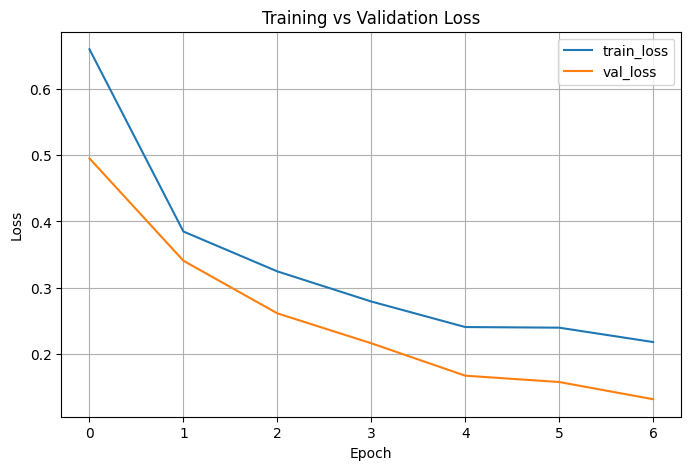

In [16]:
# =============================
# 8. Plot training history
# =============================
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)
plt.show()

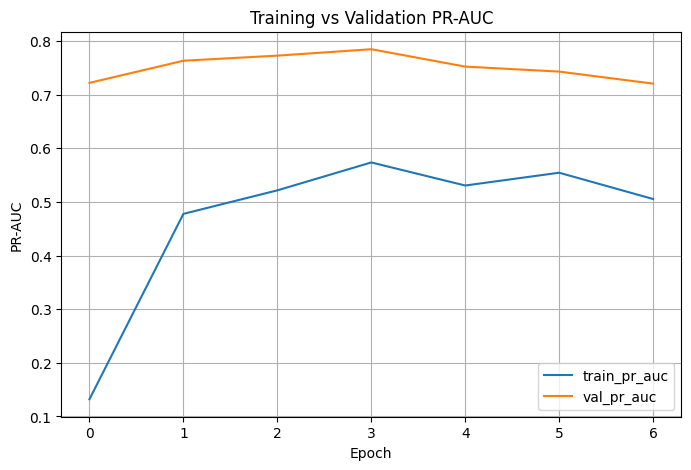

In [17]:
plt.figure(figsize=(8,5))
plt.plot(history.history["pr_auc"], label="train_pr_auc")
plt.plot(history.history["val_pr_auc"], label="val_pr_auc")
plt.xlabel("Epoch")
plt.ylabel("PR-AUC")
plt.title("Training vs Validation PR-AUC")
plt.legend()
plt.grid(True)
plt.show()

In [18]:
#check for threshold 0.9
threshold = 0.9

y_pred_adj = (y_prob >= threshold).astype(int)

from sklearn.metrics import classification_report, confusion_matrix

print("Threshold:", threshold)
print(confusion_matrix(y_test, y_pred_adj))
print(classification_report(y_test, y_pred_adj))

#the precision goes up but the recall goes down, so we miss more true positives

Threshold: 0.9
[[56814    50]
 [   14    84]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.63      0.86      0.72        98

    accuracy                           1.00     56962
   macro avg       0.81      0.93      0.86     56962
weighted avg       1.00      1.00      1.00     56962



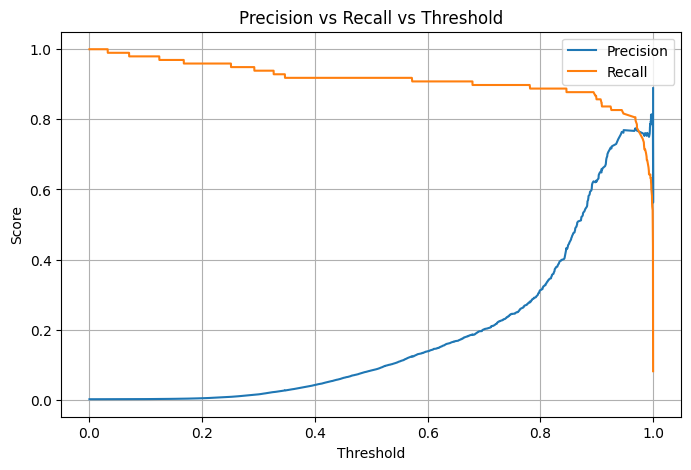

In [19]:
#plot precision and recall on threshold
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label="Precision")
plt.plot(thresholds, recall[:-1], label="Recall")

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision vs Recall vs Threshold")
plt.legend()
plt.grid()
plt.show()

In [20]:
#save the keras model
import joblib

model.save("fraud_nn_model.keras")
feature_names = [
    "Time", "V1", "V2", "V3", "V4", "V5", "V6", "V7", "V8", "V9",
    "V10", "V11", "V12", "V13", "V14", "V15", "V16", "V17", "V18", "V19",
    "V20", "V21", "V22", "V23", "V24", "V25", "V26", "V27", "V28", "Amount"
]

joblib.dump(feature_names, "feature_names.pkl")

['feature_names.pkl']